# Exploratory Data Analysis — CICIDS2017 & UNSW-NB15

Autonomous SOC Analyst Project — Phase 1, Member 2

This notebook explores the two intrusion detection datasets used to train/validate
the agentic pipeline: label distributions, feature statistics, missing values,
and attack vs. benign traffic comparisons.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ingestion.dataset_loader import load_cicids2017_sample, load_unsw_nb15_sample

sns.set_style("whitegrid")
%matplotlib inline

In [2]:
import pandas, matplotlib, seaborn
print("pandas:", pandas.__version__)
print("matplotlib:", matplotlib.__version__)
print("seaborn:", seaborn.__version__)

pandas: 2.3.3
matplotlib: 3.11.1
seaborn: 0.13.2


## 1. Load Datasets

In [2]:
cicids_df = load_cicids2017_sample(sample_size=20000, random_state=42)
unsw_df = load_unsw_nb15_sample(sample_size=20000, random_state=42)

print("CICIDS2017 shape:", cicids_df.shape)
print("UNSW-NB15 shape:", unsw_df.shape)

CICIDS2017 directory:
C:\Users\aakri\OneDrive\Desktop\SOC-Analyst\data\cicids2017\MachineLearningCVE

Found 8 CSV files:

Reading: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Reading: Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Reading: Friday-WorkingHours-Morning.pcap_ISCX.csv
Reading: Monday-WorkingHours.pcap_ISCX.csv
Reading: Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Reading: Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
Reading: Tuesday-WorkingHours.pcap_ISCX.csv
Reading: Wednesday-workingHours.pcap_ISCX.csv

Total events available: 2,830,743
UNSW-NB15 directory:
C:\Users\aakri\OneDrive\Desktop\SOC-Analyst\data\unsw_nb15

Reading: UNSW_NB15_training-set.csv
Reading: UNSW_NB15_testing-set.csv

Total events available: 257,673
CICIDS2017 shape: (20000, 79)
UNSW-NB15 shape: (20000, 45)


## 2. Label Distribution

C:\Users\aakri\AppData\Local\Temp\ipykernel_3564\2579296036.py:13: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\aakri\OneDrive\Desktop\SOC-Analyst\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


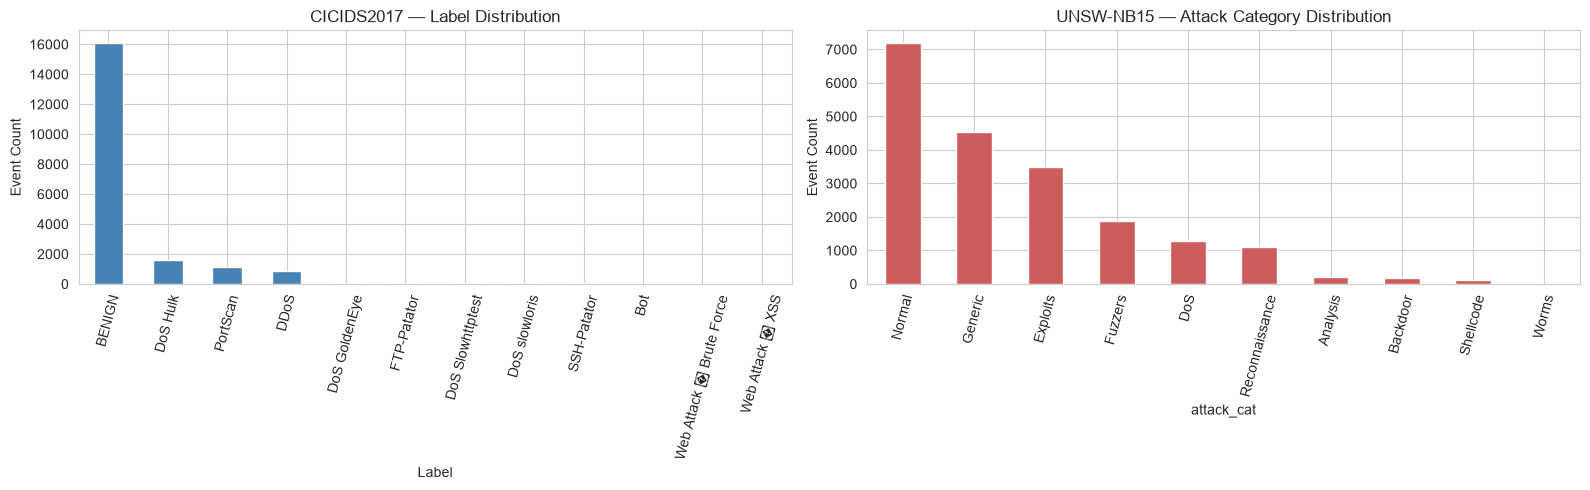

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

cicids_df["Label"].value_counts().plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("CICIDS2017 — Label Distribution")
axes[0].set_ylabel("Event Count")
axes[0].tick_params(axis="x", rotation=75)

unsw_df["attack_cat"].value_counts().plot(kind="bar", ax=axes[1], color="indianred")
axes[1].set_title("UNSW-NB15 — Attack Category Distribution")
axes[1].set_ylabel("Event Count")
axes[1].tick_params(axis="x", rotation=75)

plt.tight_layout()
plt.show()

## 3. Missing Value Checks

In [4]:
print("CICIDS2017 — Missing values per column (non-zero only):\n")
cicids_missing = cicids_df.isnull().sum()
print(cicids_missing[cicids_missing > 0])

print(f"\nTotal missing values in CICIDS2017: {cicids_df.isnull().sum().sum()}")

print("\n\nUNSW-NB15 — Missing values per column (non-zero only):\n")
unsw_missing = unsw_df.isnull().sum()
print(unsw_missing[unsw_missing > 0])

print(f"\nTotal missing values in UNSW-NB15: {unsw_df.isnull().sum().sum()}")

CICIDS2017 — Missing values per column (non-zero only):

Flow Bytes/s    8
dtype: int64

Total missing values in CICIDS2017: 8


UNSW-NB15 — Missing values per column (non-zero only):

Series([], dtype: int64)

Total missing values in UNSW-NB15: 0


**Finding:** CICIDS2017 has 8 missing values, all in `Flow Bytes/s` — a known issue in this
dataset caused by divide-by-zero when flow duration is extremely small. UNSW-NB15 has no
missing values at all in this sample.

## 4. Feature Statistics

In [6]:
import numpy as np

# Replace infinite values with NaN so describe() gives meaningful stats
cicids_clean = cicids_df.replace([np.inf, -np.inf], np.nan)

cicids_features = [
    "Flow Duration",
    "Total Fwd Packets",
    "Total Backward Packets",
    "Flow Bytes/s",
    "Flow Packets/s",
]

print("CICIDS2017 — Key Feature Statistics (inf values excluded):\n")
print(cicids_clean[cicids_features].describe())

inf_count_bytes = np.isinf(cicids_df["Flow Bytes/s"]).sum()
inf_count_packets = np.isinf(cicids_df["Flow Packets/s"]).sum()
negative_duration = (cicids_df["Flow Duration"] < 0).sum()

print(f"\nRows with infinite Flow Bytes/s: {inf_count_bytes}")
print(f"Rows with infinite Flow Packets/s: {inf_count_packets}")
print(f"Rows with negative Flow Duration: {negative_duration}")

unsw_features = ["dur", "spkts", "dpkts", "sbytes", "dbytes", "rate"]

print("\n\nUNSW-NB15 — Key Feature Statistics:\n")
print(unsw_df[unsw_features].describe())

CICIDS2017 — Key Feature Statistics (inf values excluded):

       Flow Duration  Total Fwd Packets  Total Backward Packets  Flow Bytes/s  \
count   2.000000e+04       20000.000000            20000.000000  1.997500e+04   
mean    1.460892e+07           6.340350                6.183250  1.459131e+06   
std     3.350426e+07          74.782916               84.207281  2.765937e+07   
min    -1.000000e+00           1.000000                0.000000 -1.200000e+07   
25%     1.570000e+02           2.000000                1.000000  1.186841e+02   
50%     3.127400e+04           2.000000                2.000000  4.631008e+03   
75%     2.723602e+06           5.000000                4.000000  1.600000e+05   
max     1.199994e+08        9449.000000            10063.000000  2.070000e+09   

       Flow Packets/s  
count    1.997500e+04  
mean     7.006177e+04  
std      2.568219e+05  
min     -2.000000e+06  
25%      3.532882e+00  
50%      1.141093e+02  
75%      2.285714e+04  
max      3.000000e

In [7]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

print("UNSW-NB15 — Key Feature Statistics (full view):\n")
print(unsw_df[unsw_features].describe())

UNSW-NB15 — Key Feature Statistics (full view):

                dur         spkts         dpkts        sbytes        dbytes  \
count  20000.000000  20000.000000  20000.000000  2.000000e+04  2.000000e+04   
mean       1.278696     21.262450     18.724500  1.099364e+04  1.447002e+04   
std        6.076003    170.218572    139.543131  2.209583e+05  1.834386e+05   
min        0.000000      1.000000      0.000000  2.400000e+01  0.000000e+00   
25%        0.000008      2.000000      0.000000  1.140000e+02  0.000000e+00   
50%        0.004170      4.000000      2.000000  5.200000e+02  1.780000e+02   
75%        0.687089     12.000000     10.000000  1.364000e+03  9.560000e+02   
max       59.999943   8669.000000  10872.000000  1.163118e+07  1.459086e+07   

               rate  
count  2.000000e+04  
mean   9.093710e+04  
std    1.595053e+05  
min    0.000000e+00  
25%    3.078598e+01  
50%    2.944238e+03  
75%    1.250000e+05  
max    1.000000e+06  


## 5. Attack vs. Benign Traffic Comparison

Comparing key traffic features between benign and attack events to see whether
extreme values (very high packet rates, unusual durations) are associated with
attacks specifically.

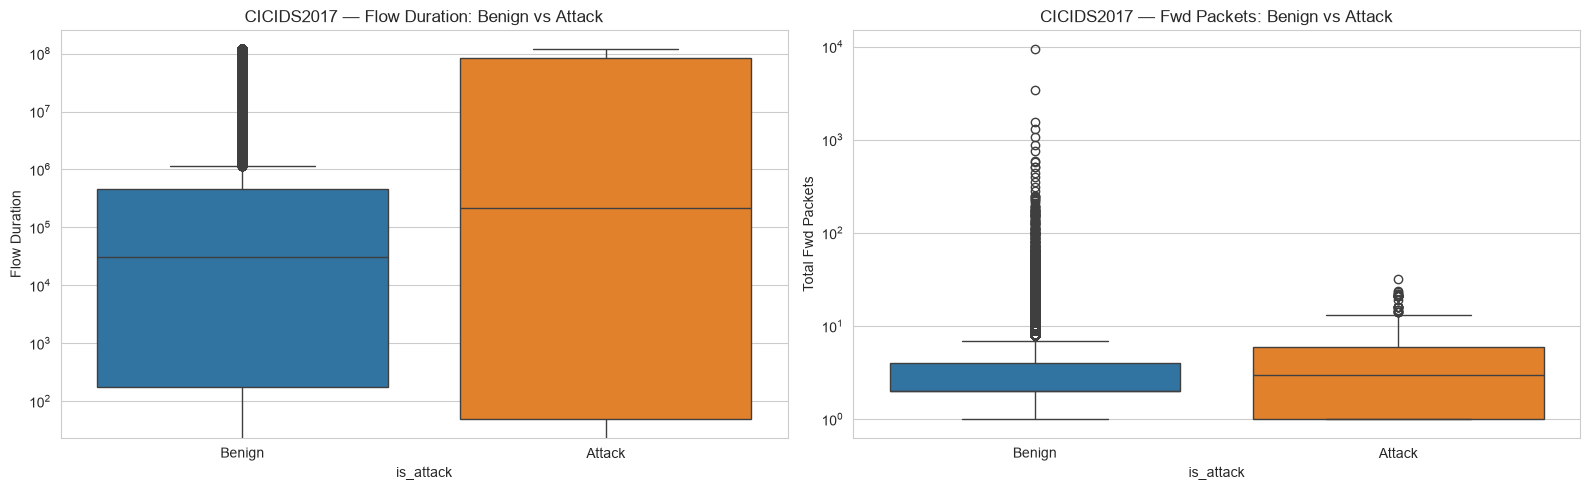

In [8]:
cicids_clean["is_attack"] = cicids_clean["Label"].apply(
    lambda x: "Benign" if x == "BENIGN" else "Attack"
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.boxplot(
    data=cicids_clean,
    x="is_attack",
    y="Flow Duration",
    ax=axes[0],
    hue="is_attack",
    legend=False,
)
axes[0].set_title("CICIDS2017 — Flow Duration: Benign vs Attack")
axes[0].set_yscale("log")

sns.boxplot(
    data=cicids_clean,
    x="is_attack",
    y="Total Fwd Packets",
    ax=axes[1],
    hue="is_attack",
    legend=False,
)
axes[1].set_title("CICIDS2017 — Fwd Packets: Benign vs Attack")
axes[1].set_yscale("log")

plt.tight_layout()
plt.show()


**Finding:** Attack traffic in CICIDS2017 tends to have longer flow durations than benign
traffic on average, consistent with sustained attacks like DoS/DDoS. However, benign traffic
actually shows more extreme high-packet-count outliers than attack traffic — likely large
legitimate data transfers. This is counterintuitive: many attacks in this dataset (PortScan,
brute-force) are low-packet, high-frequency-attempt attacks rather than high-volume floods.
This means "packet count" alone is not a reliable signal of maliciousness for this dataset.

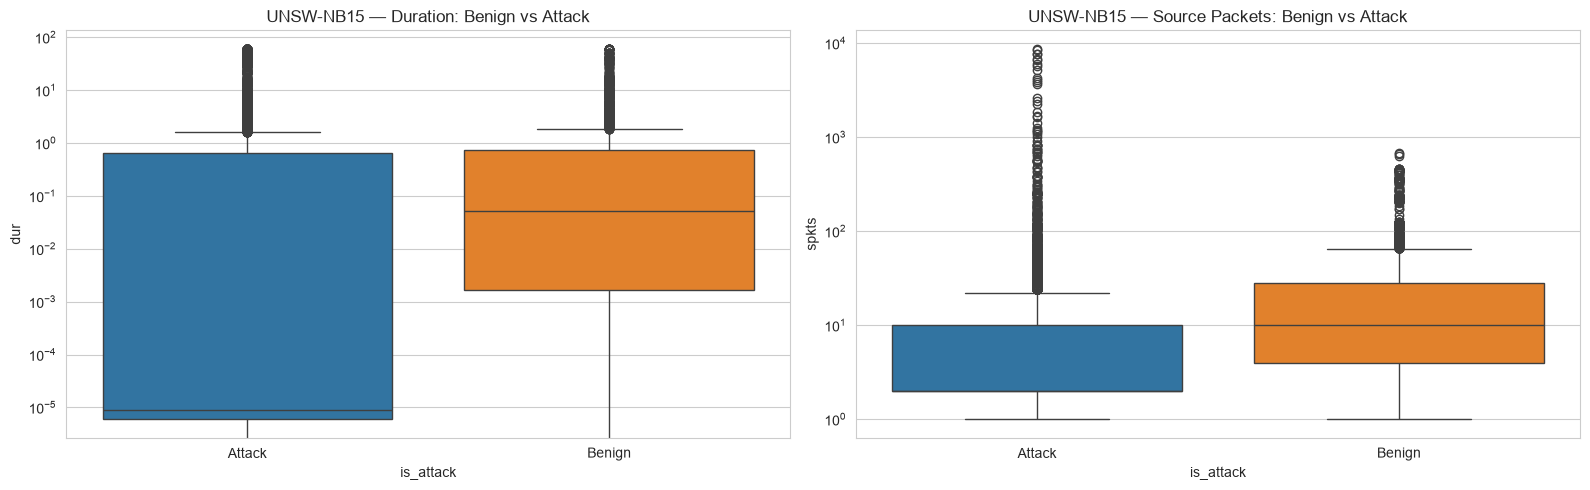

In [9]:
unsw_df["is_attack"] = unsw_df["label"].apply(
    lambda x: "Benign" if x == 0 else "Attack"
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.boxplot(
    data=unsw_df,
    x="is_attack",
    y="dur",
    ax=axes[0],
    hue="is_attack",
    legend=False,
)
axes[0].set_title("UNSW-NB15 — Duration: Benign vs Attack")
axes[0].set_yscale("log")

sns.boxplot(
    data=unsw_df,
    x="is_attack",
    y="spkts",
    ax=axes[1],
    hue="is_attack",
    legend=False,
)
axes[1].set_title("UNSW-NB15 — Source Packets: Benign vs Attack")
axes[1].set_yscale("log")

plt.tight_layout()
plt.show()

**Finding:** UNSW-NB15 shows a different, sometimes opposite pattern compared to CICIDS2017.
Here, attack traffic includes many extremely short-duration events (fast automated probes)
and has more extreme high-packet-count outliers than benign traffic — the reverse of what
CICIDS2017 showed. This confirms that simple fixed rules (e.g. "high packet count = attack")
do not generalize across datasets, and any downstream agent (especially Triage) should be
either dataset-aware or trained across both sources to avoid overfitting to one dataset's
attack patterns.

## 6. Summary of Findings

- **Class imbalance:** CICIDS2017 is heavily skewed toward benign traffic (~80% in this
  sample), with several attack types (Bot, Web Attacks) barely represented. UNSW-NB15 is
  comparatively more balanced across attack categories.
- **Data quality issues (CICIDS2017 only):** 8 missing values in `Flow Bytes/s`; a small
  number of rows with infinite `Flow Bytes/s`/`Flow Packets/s` values (17 and 25 rows
  respectively) caused by near-zero flow durations; 2 rows with an impossible negative
  `Flow Duration`. These are known, documented artifacts of this dataset and were excluded
  from statistical summaries rather than the raw data.
- **UNSW-NB15 data quality:** No missing values found in this sample.
- **Attack behavior differs by dataset:** CICIDS2017 attacks trend toward longer flow
  durations with fewer extreme packet counts than benign traffic. UNSW-NB15 attacks trend
  toward very short durations and more extreme packet-count outliers than benign traffic.
  This means packet/duration-based heuristics are not safely transferable between the two
  datasets.

**Implication for the pipeline:** the Triage and Correlation agents should not rely on a
single fixed threshold rule (e.g. packet count or duration alone) to flag traffic as
suspicious, since the relationship between these features and actual attacks differs across
data sources. Feature-based rules should either be dataset-specific or the agents should be
validated against both datasets before deployment.